# JEPA Writeup 7/27: downstream table and next steps


In [1]:
from pathlib import Path
import gc
import io
import json
import os
import subprocess

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd

from cody_jepa.single_stream_jepa import load_checkpoint


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'outputs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the cody-jepa repository root')


REPO_ROOT = find_repo_root()
OUTPUT_DIR = Path(os.environ.get(
    'CODY_JEPA_REPRO_OUTPUT_DIR',
    REPO_ROOT / 'results' / 'generated' / 'writeup-7-27-downstream',
)).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STAGE_A_RUNS = [
    ('a00-baseline', 'a00-baseline'),
    ('a01-lr3e-5', 'a01-lr3e-5'),
    ('a02-lr3e-4', 'a02-lr3e-4'),
    ('a03-ema0.995', 'a03-ema0.995'),
    ('a04-mask-light', 'a04-mask-light'),
    ('a05-mask-heavy', 'a05-mask-heavy'),
    ('a06-pred-depth3', 'a06-pred-depth3'),
    ('a07-clip-var', 'a07-clip-var'),
]
PROBE_PATHS = {
    run_id: REPO_ROOT / 'outputs' / 'pipeline' / 'phase1' / run_id / 'probes' / 'probe_metrics.csv'
    for run_id, _ in STAGE_A_RUNS
}
missing = [path for path in PROBE_PATHS.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(f'Missing probe summaries: {missing}')

print(f'Repository: {REPO_ROOT}')
print(f'Generated artifacts: {OUTPUT_DIR}')


Repository: /Users/theodoremui/dev/cody-jepa
Generated artifacts: /Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-downstream


## Load and validate downstream scores


In [2]:
probe_frames = []
for run_id, label in STAGE_A_RUNS:
    frame = pd.read_csv(PROBE_PATHS[run_id])
    frame.insert(0, 'label', label)
    frame.insert(0, 'run_id', run_id)
    probe_frames.append(frame)
probes = pd.concat(probe_frames, ignore_index=True)

expected_tasks = ['identity_closed_set', 'identity_heldout_retrieval', 'gait_system']
if set(probes['task']) != set(expected_tasks):
    raise ValueError(f'Unexpected downstream task set: {sorted(probes["task"].unique())}')
if probes.groupby('run_id').size().ne(3).any():
    raise ValueError('Each Stage A run must contain one row per downstream task')
for column in ['protocol', 'feature_source', 'train_examples', 'val_examples', 'num_classes']:
    if probes.groupby('task')[column].nunique().gt(1).any():
        raise ValueError(f'Probe comparison contract differs across runs for {column}')
for column in ['accuracy', 'balanced_accuracy', 'macro_f1']:
    if not probes[column].between(0, 1).all():
        raise ValueError(f'{column} contains a value outside [0, 1]')

score_specs = {
    'identity_closed_set': ('accuracy', 'Closed-set identity accuracy'),
    'identity_heldout_retrieval': ('accuracy', 'Held-out identity retrieval accuracy'),
    'gait_system': ('balanced_accuracy', 'Gait-system balanced accuracy'),
}
run_ids = [run_id for run_id, _ in STAGE_A_RUNS]
score_table = pd.DataFrame({
    title: probes.loc[probes['task'].eq(task)].set_index('run_id')[metric]
    for task, (metric, title) in score_specs.items()
}).reindex(run_ids)
if score_table.isna().any().any():
    raise ValueError('Downstream score table is incomplete')

raw_table_path = OUTPUT_DIR / 'writeup-7-27-downstream-values.csv'
score_table.to_csv(raw_table_path, float_format='%.17g')
print(f'Exact table values: {raw_table_path}')


Exact table values: /Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-downstream/writeup-7-27-downstream-values.csv


In [3]:
def read_worktree_or_head(relative_path: str) -> tuple[str, str]:
    path = REPO_ROOT / relative_path
    if path.is_file():
        return path.read_text(encoding='utf-8'), str(path.relative_to(REPO_ROOT))
    result = subprocess.run(
        ['git', 'show', f'HEAD:{relative_path}'],
        cwd=REPO_ROOT, capture_output=True, text=True, check=False,
    )
    if result.returncode == 0:
        return result.stdout, f'HEAD:{relative_path}'
    raise FileNotFoundError(f'{relative_path} is unavailable in the worktree and HEAD')


def require_close(label: str, observed: float, expected: float) -> None:
    if not np.isclose(observed, expected, rtol=1e-8, atol=1e-12):
        raise AssertionError(f'{label}: outputs={observed!r}, report={expected!r}')


ledger_text, ledger_source = read_worktree_or_head('reports/phase1-ledger.csv')
ledger = pd.read_csv(io.StringIO(ledger_text)).set_index('run_id')
report_columns = {
    'Closed-set identity accuracy': 'closed_set_identity',
    'Held-out identity retrieval accuracy': 'held_out_retrieval',
    'Gait-system balanced accuracy': 'gait_balanced_accuracy',
}
for run_id in run_ids:
    for table_column, report_column in report_columns.items():
        require_close(
            f'{run_id} {table_column}',
            score_table.loc[run_id, table_column],
            ledger.loc[run_id, report_column],
        )
print(f'All downstream table values match {ledger_source}')


All downstream table values match HEAD:reports/phase1-ledger.csv


## Downstream table


In [4]:
formatted = score_table.map(lambda value: f'{100.0 * value:.2f}%')
formatted.index.name = 'run_id'
formatted_path = OUTPUT_DIR / 'writeup-7-27-downstream-table.csv'
formatted.to_csv(formatted_path)
print(formatted.to_string())
print(f'Formatted table: {formatted_path}')


                Closed-set identity accuracy Held-out identity retrieval accuracy Gait-system balanced accuracy
run_id                                                                                                         
a00-baseline                          10.63%                                2.94%                        93.27%
a01-lr3e-5                             9.78%                                2.82%                        93.11%
a02-lr3e-4                             7.66%                                2.82%                        93.16%
a03-ema0.995                           8.77%                                3.00%                        93.00%
a04-mask-light                        10.31%                                3.06%                        93.75%
a05-mask-heavy                        10.74%                                2.88%                        92.90%
a06-pred-depth3                       10.26%                                3.06%                       

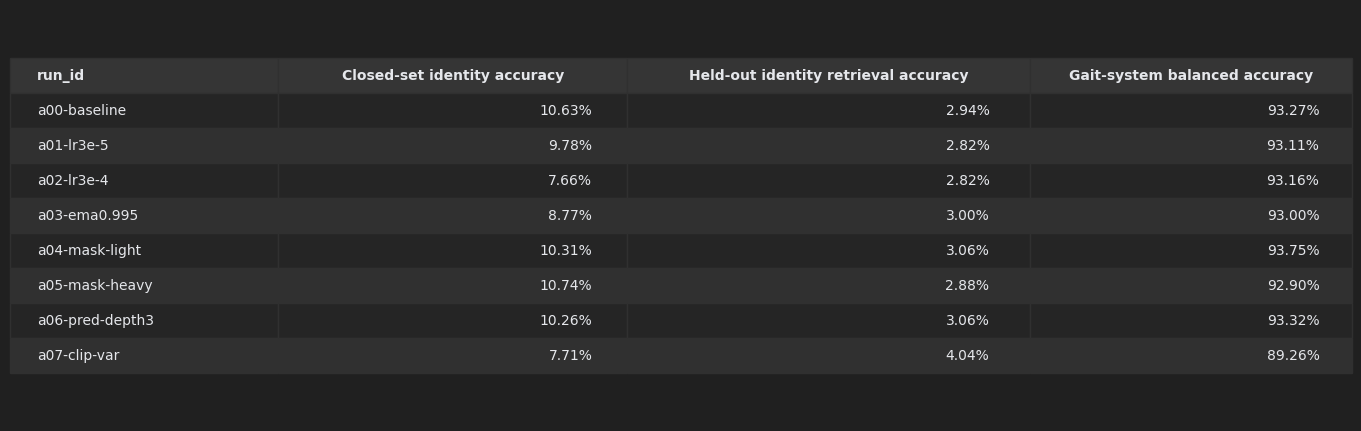

/Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-downstream/writeup-7-27-downstream-table.png


In [9]:
fig, ax = plt.subplots(figsize=(13.5, 4.2), constrained_layout=True)
fig.patch.set_facecolor('#202020')
ax.set_facecolor('#202020')
ax.axis('off')
cell_text = [[run_id, *formatted.loc[run_id].tolist()] for run_id in run_ids]
column_labels = ['run_id', *formatted.columns.tolist()]
table_artist = ax.table(
    cellText=cell_text, colLabels=column_labels,
    cellLoc='right', colLoc='center', loc='center',
    colWidths=[0.20, 0.26, 0.30, 0.24],
)
table_artist.auto_set_font_size(False)
table_artist.set_fontsize(10)
table_artist.scale(1, 1.65)
for (row, column), cell in table_artist.get_celld().items():
    cell.set_edgecolor('#303030')
    cell.get_text().set_color('#e5e7eb')
    cell.set_facecolor('#353535' if row == 0 else ('#252525' if row % 2 else '#303030'))
    if row == 0:
        cell.get_text().set_weight('bold')
    if column == 0:
        cell.get_text().set_ha('left')
table_image = OUTPUT_DIR / 'writeup-7-27-downstream-table.png'
fig.savefig(table_image, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(table_image)


In [10]:
expected_lineage = {
    'b00-clip-var': ['a07-clip-var'],
    'b01-mask-light': ['a04-mask-light'],
    'b02-mask-light-clip-var': ['a04-mask-light', 'a07-clip-var'],
}
for run_id, sources in expected_lineage.items():
    report_sources = json.loads(ledger.loc[run_id, 'source_stage_a_run_ids'])
    if report_sources != sources:
        raise AssertionError(f'{run_id}: diagram lineage disagrees with report ledger')
    checkpoint_path = REPO_ROOT / 'outputs' / 'phase1' / run_id / 'latest.pt'
    checkpoint = load_checkpoint(checkpoint_path)
    if checkpoint.get('completed_epochs') != 100 or checkpoint.get('global_step') != 3900:
        raise AssertionError(f'{run_id}: diagram budget disagrees with stored checkpoint')
    del checkpoint
    gc.collect()
print('Stage B lineage matches reports; budgets match outputs')


Stage B lineage matches reports; budgets match outputs


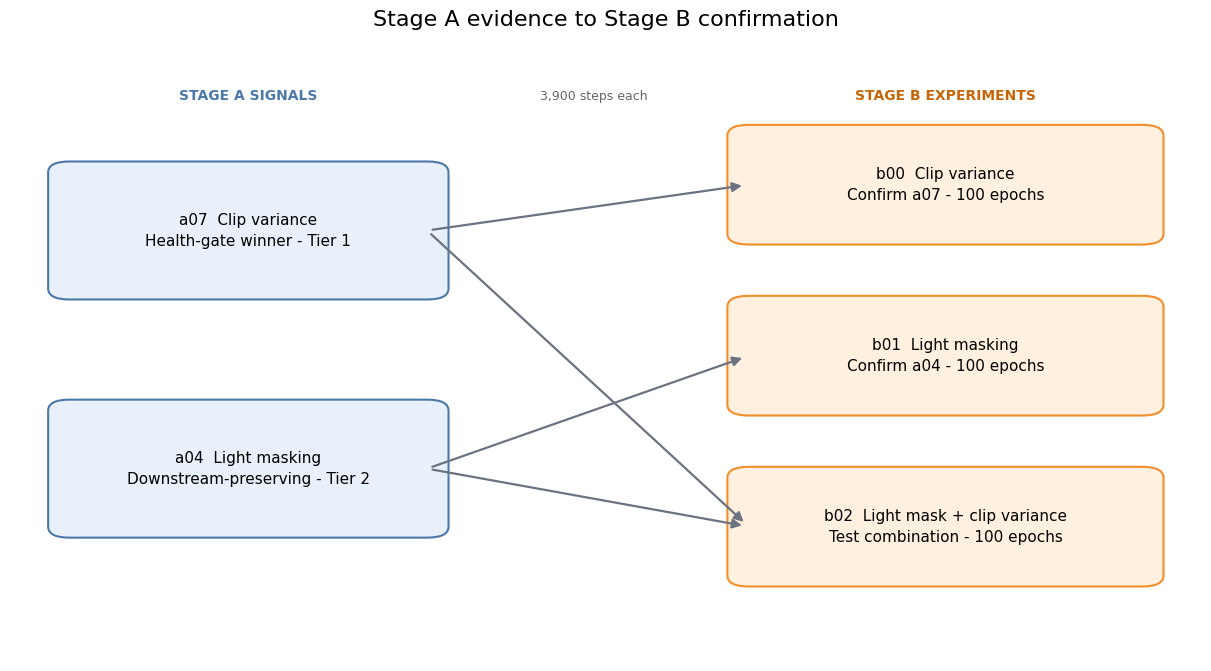

/Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-downstream/writeup-7-27-stage-b-next-steps.svg
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-downstream/writeup-7-27-stage-b-next-steps.png


In [11]:
mpl.rcParams['svg.fonttype'] = 'none'
fig, ax = plt.subplots(figsize=(12, 6.6), constrained_layout=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Stage A evidence to Stage B confirmation', fontsize=16, pad=18)

stage_a_boxes = {
    'a07-clip-var': (0.05, 0.61, 0.30, 0.19, 'a07  Clip variance\nHealth-gate winner - Tier 1'),
    'a04-mask-light': (0.05, 0.22, 0.30, 0.19, 'a04  Light masking\nDownstream-preserving - Tier 2'),
}
stage_b_boxes = {
    'b00-clip-var': (0.62, 0.70, 0.33, 0.16, 'b00  Clip variance\nConfirm a07 - 100 epochs'),
    'b01-mask-light': (0.62, 0.42, 0.33, 0.16, 'b01  Light masking\nConfirm a04 - 100 epochs'),
    'b02-mask-light-clip-var': (0.62, 0.14, 0.33, 0.16, 'b02  Light mask + clip variance\nTest combination - 100 epochs'),
}


def add_box(spec, facecolor: str, edgecolor: str) -> None:
    x, y, width, height, text = spec
    patch = FancyBboxPatch(
        (x, y), width, height, boxstyle='round,pad=0.018,rounding_size=0.018',
        linewidth=1.5, edgecolor=edgecolor, facecolor=facecolor,
    )
    ax.add_patch(patch)
    ax.text(x + width / 2, y + height / 2, text, ha='center', va='center', fontsize=11, linespacing=1.5)


for spec in stage_a_boxes.values():
    add_box(spec, '#e8f1fb', '#4c78a8')
for spec in stage_b_boxes.values():
    add_box(spec, '#fff0df', '#f28e2b')

ax.text(0.20, 0.92, 'STAGE A SIGNALS', ha='center', color='#4c78a8', weight='bold')
ax.text(0.785, 0.92, 'STAGE B EXPERIMENTS', ha='center', color='#c76608', weight='bold')
ax.text(0.49, 0.92, '3,900 steps each', ha='center', color='#666666', fontsize=9)


def right_center(spec):
    x, y, width, height, _ = spec
    return x + width, y + height / 2


def left_center(spec):
    x, y, _, height, _ = spec
    return x, y + height / 2


for target, sources in expected_lineage.items():
    for source in sources:
        ax.add_patch(FancyArrowPatch(
            right_center(stage_a_boxes[source]), left_center(stage_b_boxes[target]),
            arrowstyle='-|>', mutation_scale=14, linewidth=1.6, color='#6b7280',
            connectionstyle='arc3,rad=0.0', shrinkA=4, shrinkB=5,
        ))

diagram_path = OUTPUT_DIR / 'writeup-7-27-stage-b-next-steps.svg'
diagram_png = OUTPUT_DIR / 'writeup-7-27-stage-b-next-steps.png'
fig.savefig(diagram_path, bbox_inches='tight', metadata={'Title': 'Stage A evidence to Stage B confirmation'})
fig.savefig(diagram_png, dpi=180, bbox_inches='tight')
plt.show()
print(diagram_path)
print(diagram_png)
